# Visualize missing values for weather and consumption data

In [ ]:
import pandas as pd

# Load the raw consumption data
consumption_path = '../../../data/paraguay/electricity-consumption-raw.csv'
df_consumption = pd.read_csv(consumption_path)

In [3]:
# Identify feeder columns (assuming time columns are first, feeders are the rest)
time_cols = [col for col in df_consumption.columns if 'time' in col.lower() or 'date' in col.lower()]
feeder_cols = [col for col in df_consumption.columns if col not in time_cols]

## missing values analysis for consumption data


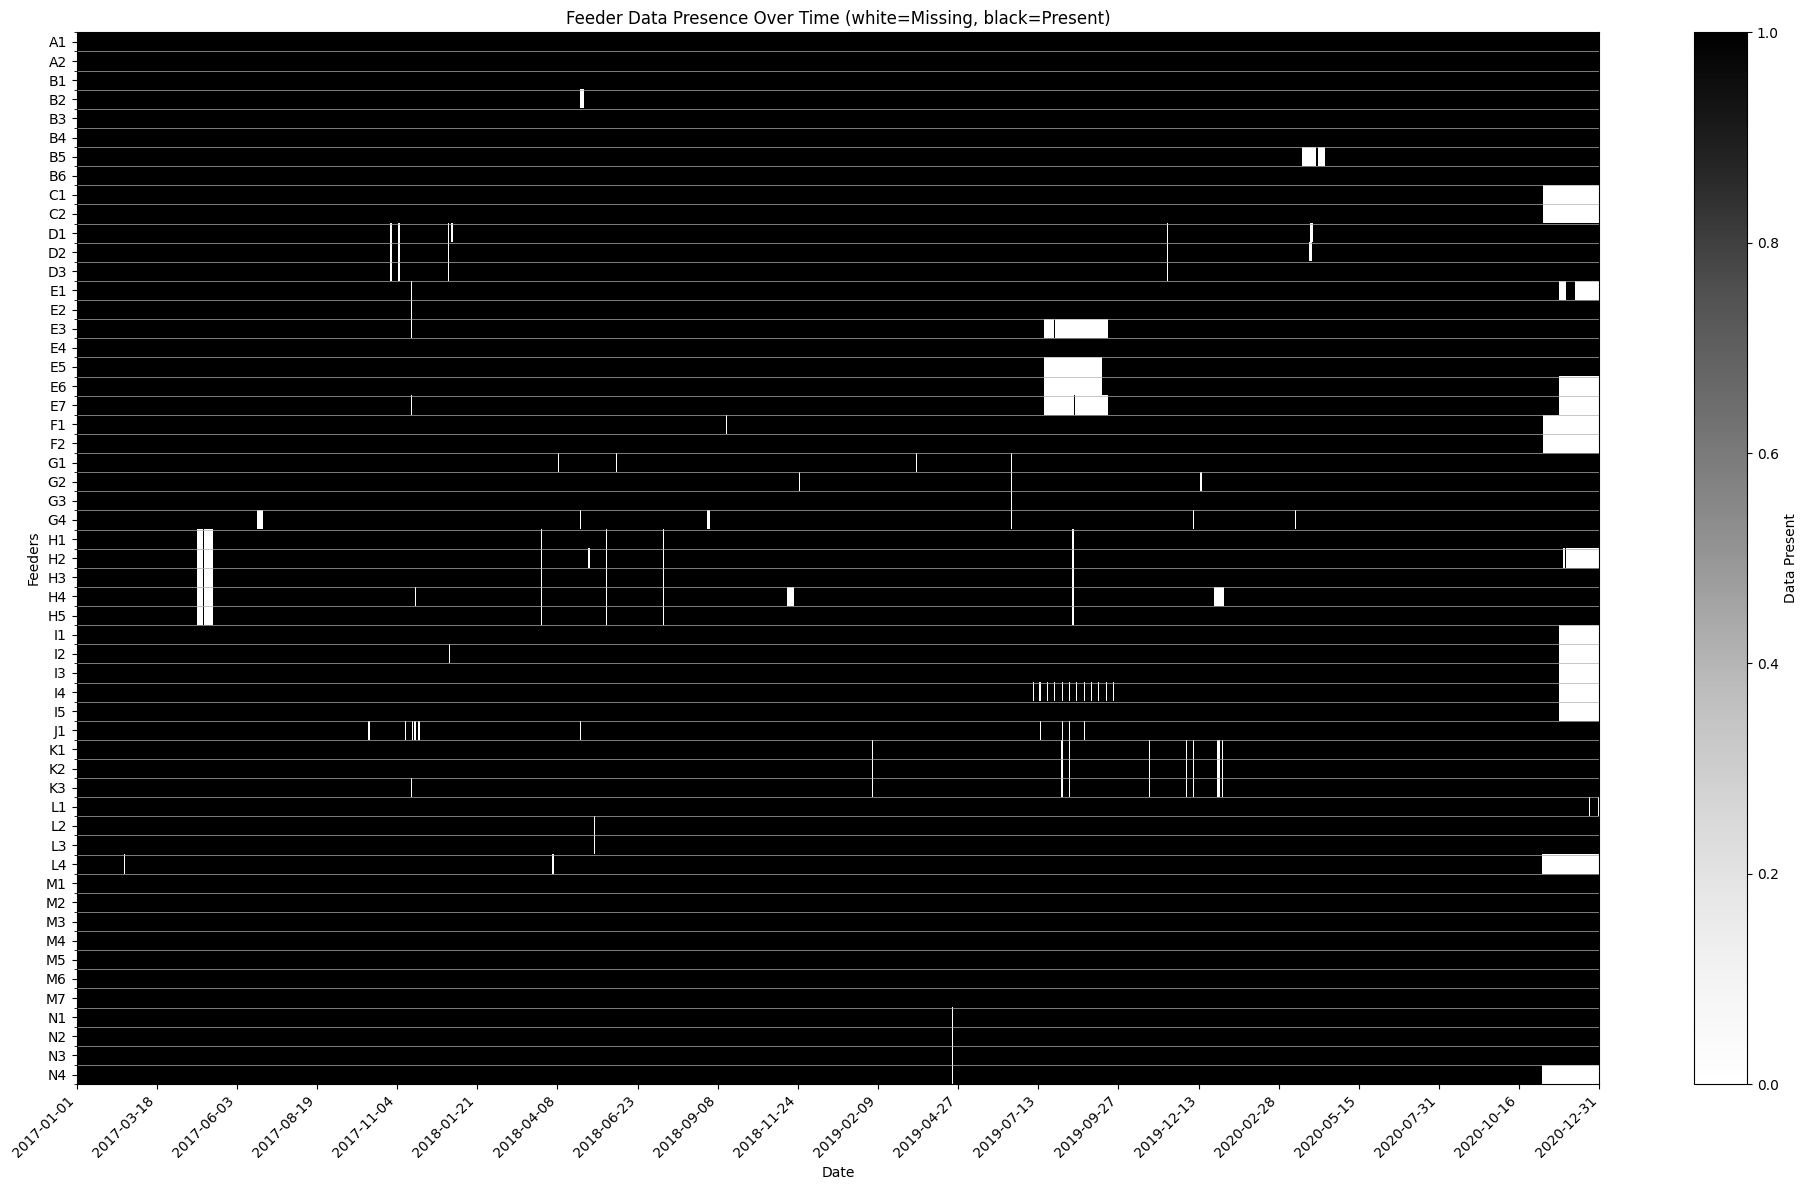

In [21]:
# Visualize feeder coverage over time with dates on x-axis
import matplotlib.pyplot as plt
import numpy as np

if 'feeder' in df_consumption.columns and time_cols:
    feeder_col = 'feeder'
    time_col = time_cols[0]
    # Convert time column to datetime if not already
    df_consumption[time_col] = pd.to_datetime(df_consumption[time_col], errors='coerce')
    presence = df_consumption.pivot(index=time_col, columns=feeder_col, values=feeder_col).notna()
    plt.figure(figsize=(20, 12))
    plt.imshow(presence.T, aspect='auto', interpolation='none', cmap='Greys')
    plt.xlabel('Date')
    plt.ylabel('Feeders')
    plt.title('Feeder Data Presence Over Time (white=Missing, black=Present)')
    # Set x-ticks to show dates, not just index numbers
    xticks = np.linspace(0, len(presence.index) - 1, min(20, len(presence.index))).astype(int)
    plt.xticks(xticks, [presence.index[i].strftime('%Y-%m-%d') if not pd.isnull(presence.index[i]) else '' for i in xticks], rotation=45, ha='right', fontsize=10)
    plt.yticks(np.arange(len(presence.columns)), presence.columns, fontsize=10)
    plt.gca().set_yticks(np.arange(-0.5, len(presence.columns), 1), minor=True)
    plt.gca().yaxis.grid(True, which='minor', linestyle='-', linewidth=0.5)
    plt.colorbar(label='Data Present')
    plt.tight_layout()
    plt.show()
else:
    print("Required columns not found for this plot.")

In [38]:
# Summarize missing data for feeders

# Calculate percent missing per feeder
missing_percent = 1 - presence.mean()
missing_percent_sorted = missing_percent.sort_values(ascending=False)

# Feeder with most and least missing data
feeder_most_missing = missing_percent_sorted.index[0]
feeder_least_missing = missing_percent_sorted.index[-1]

# Top 10 feeders with most missing data
top10_missing = missing_percent_sorted.head(10)

# Max period of missing points per feeder
def max_missing_streak(series):
    # Find the longest consecutive False (missing) streak
    return series.groupby((series != series.shift()).cumsum()).apply(lambda x: (~x).sum()).max()

max_missing_periods = presence.apply(max_missing_streak)
max_missing_period = max_missing_periods.max()
feeder_max_missing_period = max_missing_periods.idxmax()

# Total percent missing (all feeders, all times)
total_percent_missing = 1 - presence.values.mean()

print("Feeder with most missing data:", feeder_most_missing, f"({missing_percent[feeder_most_missing]*100:.2f}%)")
print("Feeder with least missing data:", feeder_least_missing, f"({missing_percent[feeder_least_missing]*100:.2f}%)")
print("\nTop 10 feeders with most missing data:")
print(top10_missing.apply(lambda x: f"{x*100:.2f}%"))
print(f"\nFeeder with longest consecutive missing period: {feeder_max_missing_period} ({max_missing_period} periods)")
print(f"\nTotal percent of missing data: {total_percent_missing*100:.2f}%")

Feeder with most missing data: E7 (6.85%)
Feeder with least missing data: M4 (0.00%)

Top 10 feeders with most missing data:
feeder
E7    6.85%
E6    6.51%
E3    4.18%
L4    4.04%
N4    3.90%
E5    3.84%
F1    3.84%
C2    3.77%
H2    3.77%
C1    3.77%
dtype: object

Feeder with longest consecutive missing period: E5 (1344 periods)

Total percent of missing data: 1.45%


In [60]:
# Load weather data to understand its structure
weather_path = '../../data/paraguay/meteorological-raw.csv'
df_weather = pd.read_csv(weather_path)

# Convert timestamp columns to datetime
weather_time_col = [col for col in df_weather.columns if 'time' in col.lower() or 'date' in col.lower()][0]
cons_time_col = time_col  # From consumption data loaded earlier

print("Weather data shape:", df_weather.shape)
print("Weather columns:", df_weather.columns.tolist())
print("\nFirst few weather timestamps:")
df_weather[weather_time_col] = pd.to_datetime(df_weather[weather_time_col], errors='coerce')
print(df_weather[weather_time_col].head(10))

print("\nFirst few consumption timestamps:")
print(df_consumption[cons_time_col].head(10))

# Get weather variable columns (excluding timestamp)
weather_vars = [col for col in df_weather.columns if col != weather_time_col]
print(f"\nWeather variables: {weather_vars}")

Weather data shape: (22445, 5)
Weather columns: ['datetime', 'temperature', 'humidity', 'wind_speed', 'pressure']

First few weather timestamps:
0   2017-01-01 00:00:00
1   2017-01-01 03:00:00
2   2017-01-01 06:00:00
3   2017-01-01 09:00:00
4   2017-01-01 12:00:00
5   2017-01-01 15:00:00
6   2017-01-01 18:00:00
7   2017-01-01 21:00:00
8   2017-01-02 00:00:00
9   2017-01-02 03:00:00
Name: datetime, dtype: datetime64[ns]

First few consumption timestamps:
0   2017-01-01 00:00:00
1   2017-01-01 01:00:00
2   2017-01-01 02:00:00
3   2017-01-01 03:00:00
4   2017-01-01 04:00:00
5   2017-01-01 05:00:00
6   2017-01-01 06:00:00
7   2017-01-01 07:00:00
8   2017-01-01 08:00:00
9   2017-01-01 09:00:00
Name: datetime, dtype: datetime64[ns]

Weather variables: ['temperature', 'humidity', 'wind_speed', 'pressure']


## Weather Data Availability Aligned with Consumption Timestamps

Weather data is measured every 3 hours, while consumption is measured hourly. Let's visualize when weather data is available for each consumption timestamp.

In [61]:
# Create a comprehensive weather availability analysis aligned with consumption timestamps

# Get unique consumption timestamps and create a full time range
consumption_times = pd.to_datetime(df_consumption[cons_time_col]).dropna().sort_values()
weather_times = pd.to_datetime(df_weather[weather_time_col]).dropna().sort_values()

# Create full hourly time range from start to end of consumption data
min_time = consumption_times.min()
max_time = consumption_times.max()
full_time_range = pd.date_range(start=min_time, end=max_time, freq='H')

print(f"Consumption data spans: {min_time} to {max_time}")
print(f"Total hours in range: {len(full_time_range)}")
print(f"Total consumption timestamps: {len(consumption_times)}")
print(f"Total weather timestamps: {len(weather_times)}")

# Create weather availability matrix for each hour and each weather variable
weather_availability = pd.DataFrame(index=full_time_range, columns=weather_vars)

# For each hour, check if weather data is available for each variable
weather_times_set = set(weather_times)
for hour_time in full_time_range:
    for var in weather_vars:
        # Check if there's weather data at this exact timestamp
        has_weather = hour_time in weather_times_set
        # Also check if the weather data for this variable is not null at this time
        if has_weather:
            weather_row = df_weather[df_weather[weather_time_col] == hour_time]
            if not weather_row.empty and not pd.isna(weather_row[var].iloc[0]):
                weather_availability.loc[hour_time, var] = 1
            else:
                weather_availability.loc[hour_time, var] = 0
        else:
            weather_availability.loc[hour_time, var] = 0

# Convert to numeric for easier plotting
weather_availability = weather_availability.astype(float)

print(f"\nWeather availability matrix shape: {weather_availability.shape}")
print(f"Overall weather data coverage:")
for var in weather_vars:
    coverage = weather_availability[var].mean() * 100
    print(f"  {var}: {coverage:.2f}%")

C:\Users\knuto\AppData\Local\Temp\ipykernel_55476\2402958519.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_time_range = pd.date_range(start=min_time, end=max_time, freq='H')


Consumption data spans: 2017-01-01 00:00:00 to 2020-12-31 23:00:00
Total hours in range: 35064
Total consumption timestamps: 1899312
Total weather timestamps: 22445

Weather availability matrix shape: (35064, 4)
Overall weather data coverage:
  temperature: 64.01%
  humidity: 63.78%
  wind_speed: 64.01%
  pressure: 64.00%


First week: 2017-01-01 00:00:00 to 2017-01-08 00:00:00
Hours in first week: 168


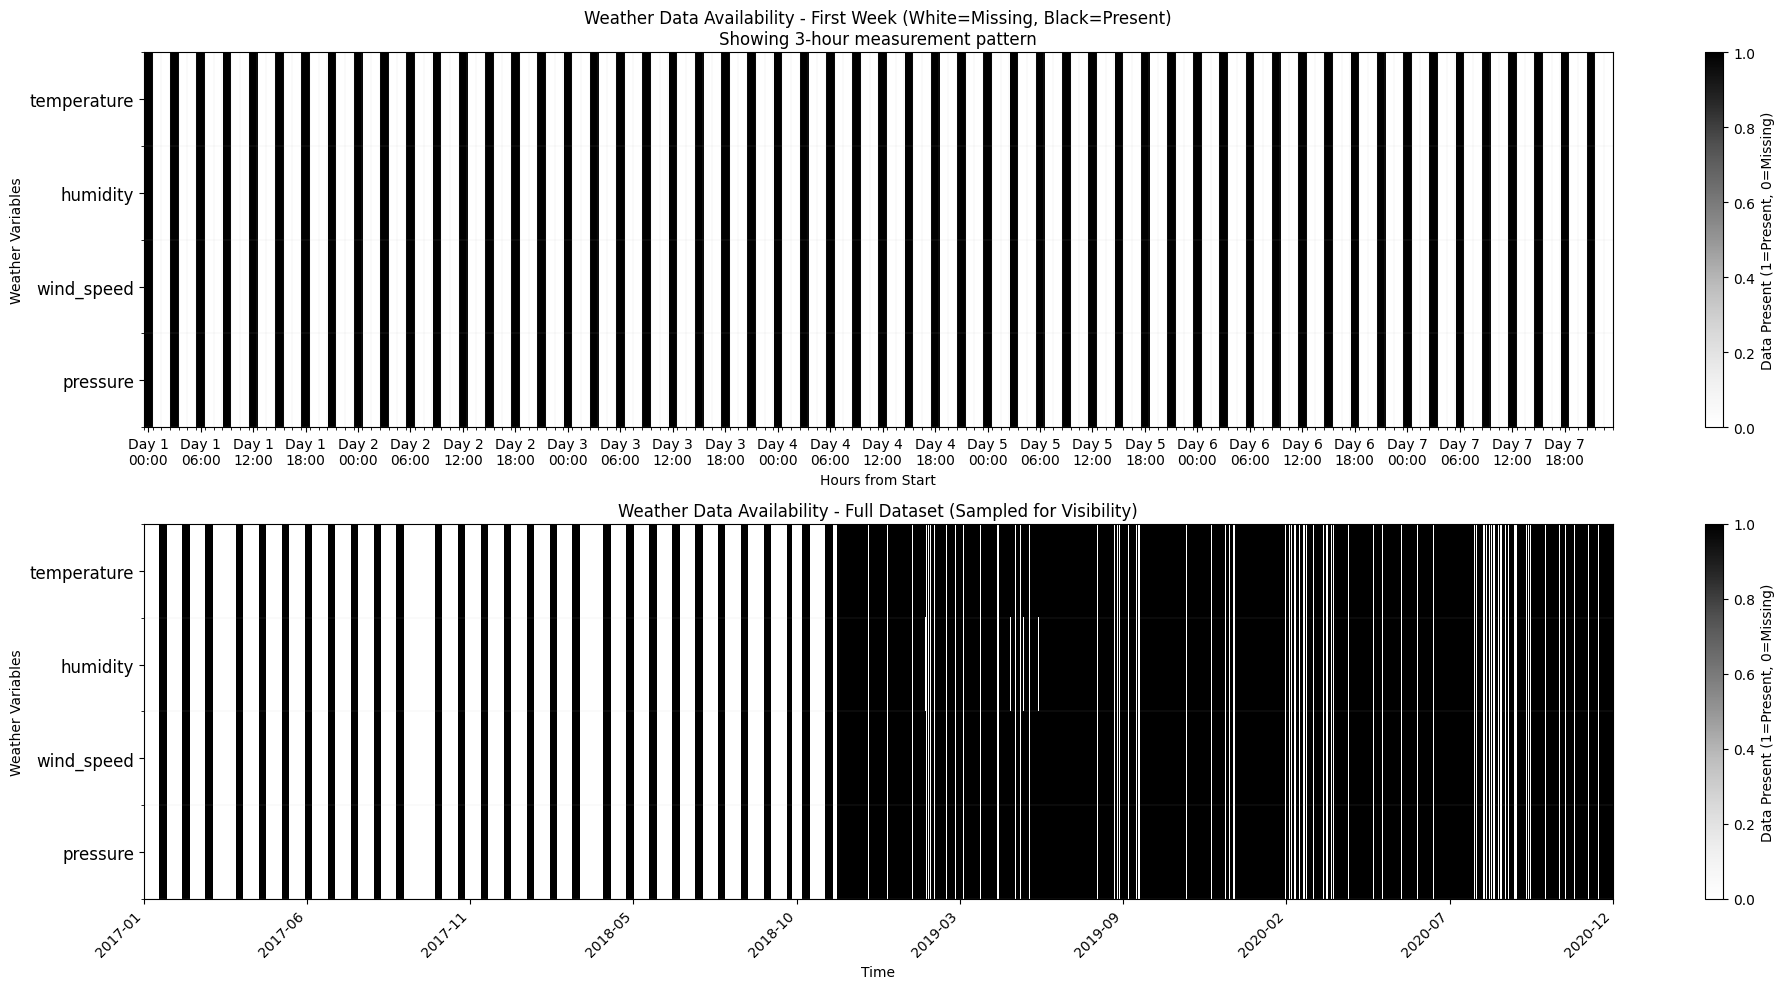

In [ ]:
# Plot weather availability for first week - showing the 3-hour pattern
first_week_start = min_time
first_week_end = first_week_start + pd.Timedelta(days=7)
first_week_mask = (weather_availability.index >= first_week_start) & (weather_availability.index < first_week_end)
first_week_data = weather_availability[first_week_mask]

print(f"First week: {first_week_start} to {first_week_end}")
print(f"Hours in first week: {len(first_week_data)}")

# Create the plot for first week
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

# First week plot
im1 = ax1.imshow(first_week_data.T, aspect='auto', interpolation='none', cmap='Greys', vmin=0, vmax=1)
ax1.set_xlabel('Hours from Start')
ax1.set_ylabel('Weather Variables')
ax1.set_title('Weather Data Availability - First Week (White=Missing, Black=Present)\nShowing 3-hour measurement pattern')

# Set x-ticks for first week (every 6 hours)
hours_in_week = np.arange(len(first_week_data))
xticks_week = np.arange(0, len(first_week_data), 6)  # Every 6 hours
hour_labels = []
for i in xticks_week:
    if i < len(first_week_data):
        time_str = f"Day {i//24 + 1}\n{(i%24):02d}:00"
        hour_labels.append(time_str)

ax1.set_xticks(xticks_week)
ax1.set_xticklabels(hour_labels, fontsize=10)
ax1.set_yticks(np.arange(len(weather_vars)))
ax1.set_yticklabels(weather_vars, fontsize=12)

# Add grid lines to show the 3-hour pattern more clearly
ax1.set_xticks(np.arange(-0.5, len(first_week_data), 1), minor=True)
ax1.set_yticks(np.arange(-0.5, len(weather_vars), 1), minor=True)
ax1.grid(True, which='minor', linestyle='-', linewidth=0.3, alpha=0.3)

# Full dataset plot (no sampling)
sampled_data = weather_availability
sampled_indices = np.arange(0, len(weather_availability), 1)

im2 = ax2.imshow(sampled_data.T, aspect='auto', interpolation='none', cmap='Greys', vmin=0, vmax=1)
ax2.set_xlabel('Time')
ax2.set_ylabel('Weather Variables')
ax2.set_title('Weather Data Availability - Full Dataset')

# Set x-ticks for full dataset
xticks = np.linspace(0, len(sampled_data) - 1, 10).astype(int)
date_labels = []
for i in xticks:
    if i < len(sampled_data):
        date_labels.append(sampled_data.index[i].strftime('%Y-%m'))

ax2.set_xticks(xticks)
ax2.set_xticklabels(date_labels, rotation=45, ha='right', fontsize=10)
ax2.set_yticks(np.arange(len(weather_vars)))
ax2.set_yticklabels(weather_vars, fontsize=12)

# Add grid lines
ax2.set_yticks(np.arange(-0.5, len(weather_vars), 1), minor=True)
ax2.grid(True, which='minor', axis='y', linestyle='-', linewidth=0.3, alpha=0.3)

# Add colorbars
plt.colorbar(im1, ax=ax1, label='Data Present (1=Present, 0=Missing)')
plt.colorbar(im2, ax=ax2, label='Data Present (1=Present, 0=Missing)')

plt.tight_layout()
plt.show()

In [63]:
# Analysis of the weather measurement pattern
print("=== Weather Measurement Pattern Analysis ===")
print(f"Weather measurements are taken every 3 hours starting at 00:00, 03:00, 06:00, etc.")
print(f"This means for every 3 consecutive hours of consumption data, only 1 hour has weather data.")
print()

# Verify the 3-hour pattern in the first week
first_24_hours = first_week_data.head(24)
print("First 24 hours weather availability pattern:")
print("Hour | Temp | Humid | Wind | Pressure")
print("-" * 40)
for i in range(24):
    hour = i
    temp_status = "Present" if first_24_hours.iloc[i]['temperature'] == 1 else "Missing"
    humid_status = "Present" if first_24_hours.iloc[i]['humidity'] == 1 else "Missing" 
    wind_status = "Present" if first_24_hours.iloc[i]['wind_speed'] == 1 else "Missing"
    pressure_status = "Present" if first_24_hours.iloc[i]['pressure'] == 1 else "Missing"
    print(f"{hour:2d}:00 | {temp_status:7s} | {humid_status:7s} | {wind_status:7s} | {pressure_status:7s}")

print()
print("=== Overall Statistics ===")
total_hours = len(weather_availability)
total_with_weather = int(weather_availability['temperature'].sum())  # Using temperature as representative
total_without_weather = total_hours - total_with_weather
percentage_with_weather = (total_with_weather / total_hours) * 100

print(f"Total hours analyzed: {total_hours:,}")
print(f"Hours with weather data: {total_with_weather:,} ({percentage_with_weather:.2f}%)")
print(f"Hours without weather data: {total_without_weather:,} ({100-percentage_with_weather:.2f}%)")
print(f"Expected pattern: ~33.33% coverage (1 in every 3 hours)")

# Check if there are any gaps in the weather data pattern
weather_times_unique = df_weather[weather_time_col].dropna().sort_values()
weather_diffs = weather_times_unique.diff().dropna()
expected_diff = pd.Timedelta(hours=3)
unexpected_gaps = weather_diffs[weather_diffs != expected_diff]

if len(unexpected_gaps) > 0:
    print(f"\nFound {len(unexpected_gaps)} periods with unexpected time gaps in weather data:")
    print("(This indicates missing weather measurements beyond the normal 3-hour pattern)")
else:
    print(f"\nWeather data follows a consistent 3-hour measurement pattern with no unexpected gaps.")

=== Weather Measurement Pattern Analysis ===
Weather measurements are taken every 3 hours starting at 00:00, 03:00, 06:00, etc.
This means for every 3 consecutive hours of consumption data, only 1 hour has weather data.

First 24 hours weather availability pattern:
Hour | Temp | Humid | Wind | Pressure
----------------------------------------
 0:00 | Present | Present | Present | Present
 1:00 | Missing | Missing | Missing | Missing
 2:00 | Missing | Missing | Missing | Missing
 3:00 | Present | Present | Present | Present
 4:00 | Missing | Missing | Missing | Missing
 5:00 | Missing | Missing | Missing | Missing
 6:00 | Present | Present | Present | Present
 7:00 | Missing | Missing | Missing | Missing
 8:00 | Missing | Missing | Missing | Missing
 9:00 | Present | Present | Present | Present
10:00 | Missing | Missing | Missing | Missing
11:00 | Missing | Missing | Missing | Missing
12:00 | Present | Present | Present | Present
13:00 | Missing | Missing | Missing | Missing
14:00 | Mis

## Weather Measurements Per Day Over Time

Let's analyze how the frequency of weather measurements changes over time by counting the number of measurements per day.

In [72]:
# Calculate daily weather measurement counts
# Create a date column from the weather timestamps
df_weather['date'] = df_weather[weather_time_col].dt.date

# Count measurements per day
daily_counts = df_weather.groupby('date').size().reset_index(name='measurements_per_day')
daily_counts['date'] = pd.to_datetime(daily_counts['date'])

# Create a complete date range to fill in missing days
date_range = pd.date_range(start=daily_counts['date'].min(), end=daily_counts['date'].max(), freq='D')
complete_daily = pd.DataFrame({'date': date_range})
complete_daily = complete_daily.merge(daily_counts, on='date', how='left')
complete_daily['measurements_per_day'] = complete_daily['measurements_per_day'].fillna(0)

print(f"Date range: {daily_counts['date'].min()} to {daily_counts['date'].max()}")
print(f"Total days: {len(complete_daily)}")
print(f"Days with measurements: {(complete_daily['measurements_per_day'] > 0).sum()}")
print(f"Days without measurements: {(complete_daily['measurements_per_day'] == 0).sum()}")
print(f"Average measurements per day: {complete_daily['measurements_per_day'].mean():.2f}")
print(f"Expected measurements per day: 8 (every 3 hours: 00:00, 03:00, 06:00, 09:00, 12:00, 15:00, 18:00, 21:00)")

# Show statistics
print(f"\nMeasurements per day statistics:")
print(f"Min: {complete_daily['measurements_per_day'].min()}")
print(f"Max: {complete_daily['measurements_per_day'].max()}")
print(f"Median: {complete_daily['measurements_per_day'].median()}")
print(f"Most common count: {complete_daily['measurements_per_day'].mode().iloc[0] if not complete_daily['measurements_per_day'].mode().empty else 'N/A'}")

# Count frequency of different measurement counts
count_frequency = complete_daily['measurements_per_day'].value_counts().sort_index()
print(f"\nFrequency of measurement counts per day:")
for count, freq in count_frequency.items():
    percentage = (freq / len(complete_daily)) * 100
    print(f"  {int(count)} measurements: {freq} days ({percentage:.1f}%)")

Date range: 2017-01-01 00:00:00 to 2020-12-31 00:00:00
Total days: 1461
Days with measurements: 1460
Days without measurements: 1
Average measurements per day: 15.36
Expected measurements per day: 8 (every 3 hours: 00:00, 03:00, 06:00, 09:00, 12:00, 15:00, 18:00, 21:00)

Measurements per day statistics:
Min: 0.0
Max: 24.0
Median: 18.0
Most common count: 8.0

Frequency of measurement counts per day:
  0 measurements: 1 days (0.1%)
  7 measurements: 3 days (0.2%)
  8 measurements: 683 days (46.7%)
  9 measurements: 2 days (0.1%)
  10 measurements: 1 days (0.1%)
  12 measurements: 1 days (0.1%)
  13 measurements: 1 days (0.1%)
  14 measurements: 1 days (0.1%)
  15 measurements: 2 days (0.1%)
  16 measurements: 7 days (0.5%)
  17 measurements: 12 days (0.8%)
  18 measurements: 23 days (1.6%)
  19 measurements: 43 days (2.9%)
  20 measurements: 60 days (4.1%)
  21 measurements: 106 days (7.3%)
  22 measurements: 127 days (8.7%)
  23 measurements: 216 days (14.8%)
  24 measurements: 172 days

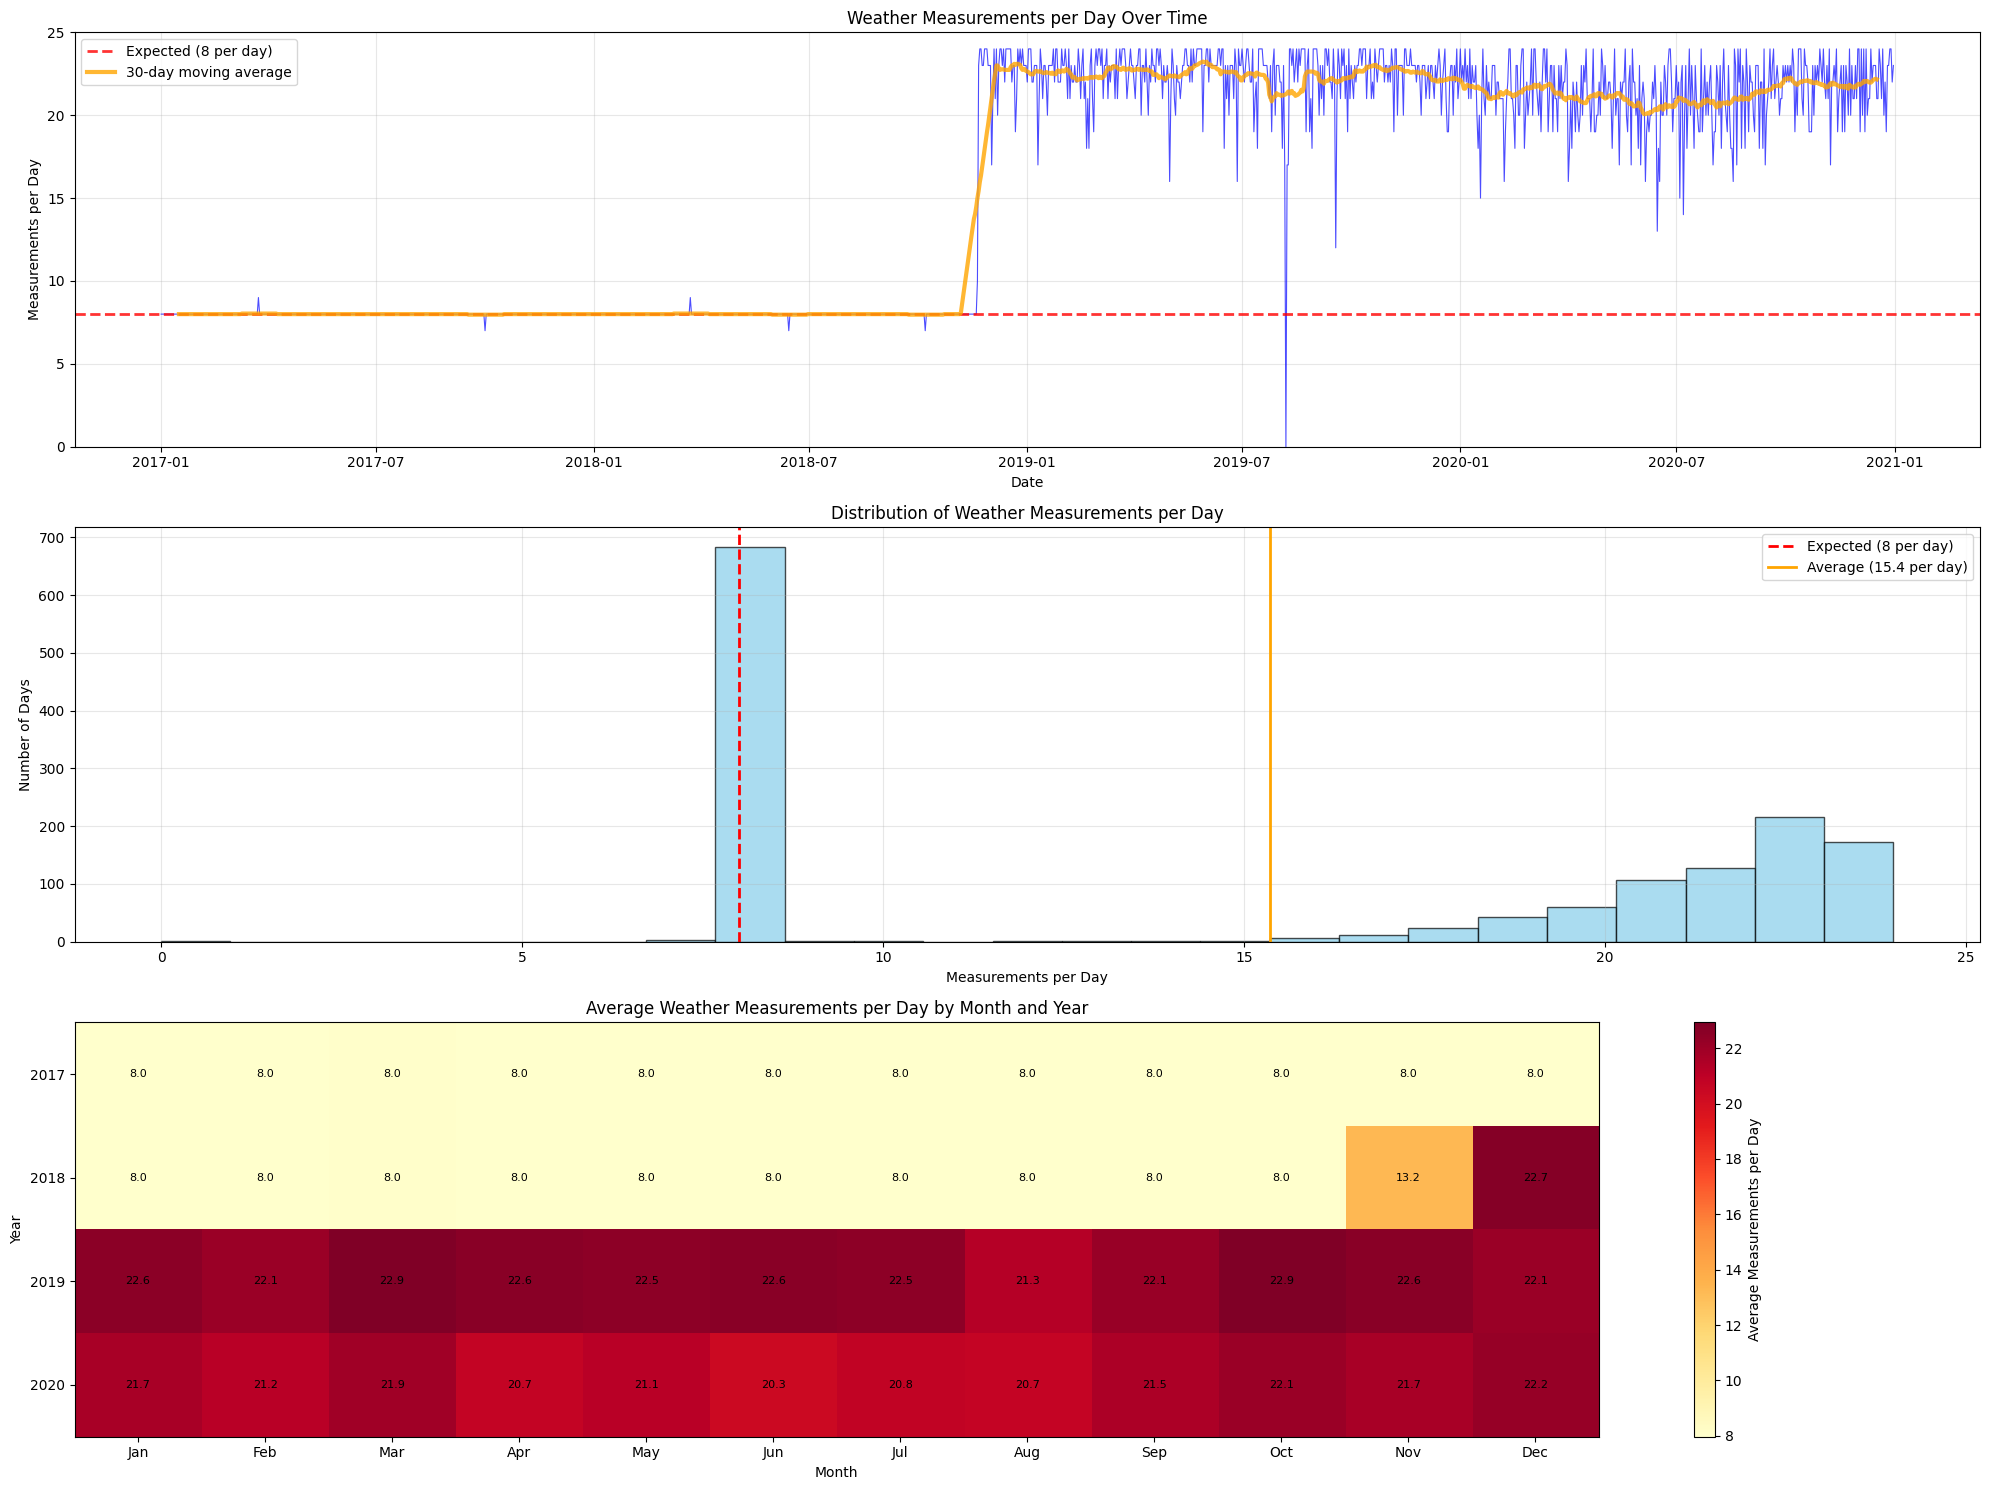

In [73]:
# Create visualization of measurements per day over time
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(20, 15))

# Plot 1: Time series of measurements per day
ax1.plot(complete_daily['date'], complete_daily['measurements_per_day'], linewidth=0.8, alpha=0.7, color='blue')
ax1.axhline(y=8, color='red', linestyle='--', linewidth=2, label='Expected (8 per day)', alpha=0.8)
ax1.set_xlabel('Date')
ax1.set_ylabel('Measurements per Day')
ax1.set_title('Weather Measurements per Day Over Time')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.set_ylim(0, 25)

# Add a 30-day moving average
window_size = 30
moving_avg = complete_daily['measurements_per_day'].rolling(window=window_size, center=True).mean()
ax1.plot(complete_daily['date'], moving_avg, linewidth=3, color='orange', label=f'{window_size}-day moving average', alpha=0.8)
ax1.legend()

# Plot 2: Distribution of measurements per day (histogram)
ax2.hist(complete_daily['measurements_per_day'], bins=25, edgecolor='black', alpha=0.7, color='skyblue')
ax2.axvline(x=8, color='red', linestyle='--', linewidth=2, label='Expected (8 per day)')
ax2.axvline(x=complete_daily['measurements_per_day'].mean(), color='orange', linestyle='-', linewidth=2, 
           label=f'Average ({complete_daily["measurements_per_day"].mean():.1f} per day)')
ax2.set_xlabel('Measurements per Day')
ax2.set_ylabel('Number of Days')
ax2.set_title('Distribution of Weather Measurements per Day')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Heatmap showing patterns by year and month
complete_daily['year'] = complete_daily['date'].dt.year
complete_daily['month'] = complete_daily['date'].dt.month

# Create pivot table for heatmap
monthly_avg = complete_daily.groupby(['year', 'month'])['measurements_per_day'].mean().unstack()

im = ax3.imshow(monthly_avg.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax3.set_xticks(range(12))
ax3.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax3.set_yticks(range(len(monthly_avg.index)))
ax3.set_yticklabels(monthly_avg.index)
ax3.set_xlabel('Month')
ax3.set_ylabel('Year')
ax3.set_title('Average Weather Measurements per Day by Month and Year')

# Add colorbar
cbar = plt.colorbar(im, ax=ax3)
cbar.set_label('Average Measurements per Day')

# Add text annotations to heatmap
for i in range(len(monthly_avg.index)):
    for j in range(12):
        if not pd.isna(monthly_avg.iloc[i, j]):
            text = ax3.text(j, i, f'{monthly_avg.iloc[i, j]:.1f}',
                           ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.show()